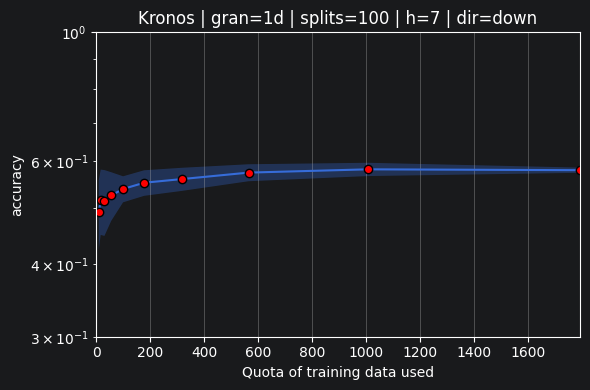

In [3]:
# print the accuracy and precision learning curve
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



def plot_learning_curve(
    df,
    save_path,
    display=False,
    metric=None,
    gran=None,
    m1=None,
    n_splits=None,
    forecast_horizon=None,
    direction=None
):
    # Ensure correct column order
    df = df.reindex(sorted(df.columns, key=float), axis=1)

    x = df.columns.astype(float).to_numpy()
    y_mean = df.mean(axis=0).to_numpy()
    y_std = df.std(axis=0).to_numpy()

    lower = np.clip(y_mean - y_std, 0, 1)
    upper = np.clip(y_mean + y_std, 0, 1)

    plt.figure(figsize=(6, 4))
    plt.plot(x, y_mean, marker='o', markerfacecolor='r', markeredgecolor='k', label='mean')
    plt.fill_between(x, lower, upper, alpha=0.3)

    plt.xlabel("Quota of training data used")
    plt.ylabel(f"{metric}")
    plt.ylim(0.3, 1)
    plt.xlim(0, np.max(x)+0.5)
    plt.yscale("log")

    # Title
    title_parts = []
    if m1: title_parts.append(f"{m1}")
    if gran: title_parts.append(f"gran={gran}")
    if n_splits: title_parts.append(f"splits={n_splits}")
    if forecast_horizon: title_parts.append(f"h={forecast_horizon}")
    if direction: title_parts.append(f"dir={direction}")

    plt.title(" | ".join(title_parts))

    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
    if display:
        plt.show()


dir_path = "/Volumes/Data/other/2026_NII/Output"
direction = "down"  # or up
forecast_horizon = 7  # can only be 7 atm
m1 = "Kronos"  # Kronos or Fincast
n_splits = 100
gran = "1d"

data_acc = pd.read_csv(os.path.join(dir_path, m1, f"/home/till/PycharmProjects/Secondary-Model/src/Output/Kronos/interpretability/learning_curves/direction=up/1d/acc_test_multi_7_fee_n_splits=100.csv"))
# data_prec = pd.read_csv(os.path.join(dir_path, m1, f"interpretability/learning_curves/"
#                                                    f"precision_multi_{forecast_horizon}_fee_direction={direction}_gran={gran}.csv"))

plot_learning_curve(
    data_acc,
    save_path=False,
    display=False,
    metric="accuracy",
    gran=gran,
    m1=m1,
    n_splits=n_splits,
    forecast_horizon=forecast_horizon,
    direction=direction
)

# plot_learning_curve(
#     data_prec,
#     save_path=False,
#     display=True,
#     metric="precision",
#     gran=gran,
#     m1=m1,
#     n_splits=n_splits,
#     forecast_horizon=forecast_horizon,
#     direction=direction
# )


In [8]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))  # try current dir
sys.path.insert(0, str(Path.cwd().parent))  # or parent
import Utils

import pandas as pd
import torch
from Utils.utils import _load_multi_cache
from Utils.data import split_by_global_time, ENG_FEATURE_NAMES

multi = _load_multi_cache("/home/till/PycharmProjects/Secondary-Model/src/Output/Kronos/cache/multi_7_fee_up_7b548bc3e5.pt")

gran = "1d"
sub = multi.sub[gran]

sub = multi.sub[gran]
idx_train, _, idx_val, idx_test = split_by_global_time(sub, train_end="2025-05-30", val_end="2025-10-01")
eng_raw = sub["eng_features"].numpy() if isinstance(sub["eng_features"], torch.Tensor) else sub["eng_features"]
labels_raw = sub["labels"].numpy() if isinstance(sub["labels"], torch.Tensor) else sub["labels"]


X_train = pd.DataFrame(eng_raw[idx_train], columns=ENG_FEATURE_NAMES, index=[sub["dates"][i] for i in idx_train])
y_train = labels_raw[idx_train].astype(int)

X_val = pd.DataFrame(eng_raw[idx_val], columns=ENG_FEATURE_NAMES, index=[sub["dates"][i] for i in idx_val])
y_val = labels_raw[idx_val].astype(int)

X_test = pd.DataFrame(eng_raw[idx_test], columns=ENG_FEATURE_NAMES, index=[sub["dates"][i] for i in idx_test])
y_test = labels_raw[idx_test].astype(int)





┏━━━━━━━━━━ Splitting dataset by global time ━━━━━━━━━━┓
[split_by_global_time] Total: 11,402 Windows → 3,216 with valid labels (8,186 had NaN meta_label, filtered out)
[split_by_global_time] Date-based split (meta absorbed):
    Train: ≤ 2025-05-30 00:00:00  (1,795 samples)
    Val:   ≤ 2025-10-01 00:00:00  (695 samples)
    Test:  > 2025-10-01 00:00:00  (726 samples)
            ret_mean   ret_std  ret_skew  ret_kurt  trend_slope  trend_r2  \
2024-06-30  0.001318  0.032221  0.298328 -0.254621    -0.005004  0.441763   
2024-07-01 -0.006603  0.036772 -0.269343  0.191483    -0.009304  0.752383   
2024-07-01  0.000612  0.031733  0.343424 -0.094359    -0.004816  0.414698   
2024-07-02 -0.002201  0.021515  0.032071 -0.613122    -0.005675  0.784372   
2024-07-03 -0.003138  0.018035 -0.380700 -0.571512    -0.004149  0.853657   

            reversal_count  max_drawdown    atr_last  atr_norm_last  ...  \
2024-06-30        0.421053      0.263163    5.528682       0.056745  ...   
2024-07-01  

In [8]:
import numpy as np
idx_train, _, idx_val, idx_test = split_by_global_time(sub, train_end="2025-05-30", val_end="2025-10-01")
eng_raw = sub["eng_features"].numpy() if isinstance(sub["eng_features"], torch.Tensor) else sub["eng_features"]
labels_raw = sub["labels"].numpy() if isinstance(sub["labels"], torch.Tensor) else sub["labels"]

X_train = pd.DataFrame(eng_raw[idx_train], columns=ENG_FEATURE_NAMES)
y_train = labels_raw[idx_train].astype(int)

X_val = pd.DataFrame(eng_raw[idx_val], columns=ENG_FEATURE_NAMES)
y_val = labels_raw[idx_val].astype(int)

X_test = pd.DataFrame(eng_raw[idx_test], columns=ENG_FEATURE_NAMES)
y_test = labels_raw[idx_test].astype(int)

# labels inverse
y_train_inverse = 1 - y_train

# labels random shuffle
y_train_shuffled = y_train.copy()
np.random.shuffle(y_train_shuffled)


┏━━━━━━━━━━ Splitting dataset by global time ━━━━━━━━━━┓
[split_by_global_time] Total: 11,402 Windows → 3,216 with valid labels (8,186 had NaN meta_label, filtered out)
[split_by_global_time] Date-based split (meta absorbed):
    Train: ≤ 2025-05-30 00:00:00  (1,795 samples)
    Val:   ≤ 2025-10-01 00:00:00  (695 samples)
    Test:  > 2025-10-01 00:00:00  (726 samples)


In [7]:
# train random forrest
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score

clf = RandomForestClassifier(n_estimators=500,
                                 max_depth=6,
                                 min_samples_leaf=20,
                                 random_state=42,
                                 n_jobs=-1,
                                 class_weight="balanced")

clf_inverse = clone(clf)
clf_shuffled = clone(clf)

clf.fit(X_train, y_train)
clf_inverse.fit(X_train, y_train_inverse)
clf_shuffled.fit(X_train, y_train_shuffled)

y_pred_train = clf.predict(X_train)
y_pred_shuffled_train = clf_shuffled.predict(X_train)
y_pred_inverse_train = clf_inverse.predict(X_train)

y_pred = clf.predict(X_val)
y_pred_shuffled = clf_shuffled.predict(X_val)
y_pred_inverse = clf_inverse.predict(X_val)

y_pred_test = clf.predict(X_test)
y_pred_shuffled_test = clf_shuffled.predict(X_test)
y_pred_inverse_test = clf_inverse.predict(X_test)

for name, c, y_xx in zip(["normal", "inverse", "shuffled"], [clf, clf_inverse, clf_shuffled], [y_train, y_train_inverse, y_train_shuffled]):
    y_pred_train = c.predict(X_train)
    y_pred_val = c.predict(X_val)
    y_pred_test = c.predict(X_test)
    print(f"{name}: {accuracy_score(y_xx, y_pred_train):.4f} {accuracy_score(y_val, y_pred_val)} {accuracy_score(y_test, y_pred_test)}")


normal: 0.8184 0.5294964028776978 0.5881542699724518
inverse: 0.8184 0.47050359712230216 0.4118457300275482
shuffled: 0.7632 0.4201438848920863 0.4669421487603306


In [10]:
def dist_str(y):
    counts = np.bincount(y)
    pcts = counts / len(y) * 100
    return " | ".join([f"{i}: {c} ({p:.1f}%)" for i, (c, p) in enumerate(zip(counts, pcts))])

print(f"Train: {dist_str(y_train)}")
print(f"Val:   {dist_str(y_val)}")
print(f"Test:  {dist_str(y_test)}")

Train: 0: 938 (52.3%) | 1: 857 (47.7%)
Val:   0: 275 (39.6%) | 1: 420 (60.4%)
Test:  0: 412 (56.7%) | 1: 314 (43.3%)


In [2]:
%matplotlib notebook
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))  # try current dir
sys.path.insert(0, str(Path.cwd().parent))  # or parent
import Utils.ts_cross_validation as tscv

# import Utils
# import Utils.ts_cross_validation.combinatorial_purged_cv as mod
# print(dir(mod))
# from Utils.ts_cross_validation import (
#     CombinatorialPurgedCV,
#     PurgedEmbargoTimeSeriesCV,
#     SklearnTimeSeriesCV
# )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# -----------------------------------
# Dummy Data
# -----------------------------------
n_samples = 100
dates = pd.date_range("2020-01-01", periods=n_samples, freq="D")

X = pd.DataFrame({"feature": np.random.randn(n_samples)}, index=dates)
y = np.random.randint(0, 2, size=n_samples)

# Label end times (t1) → simulate horizon
t1 = pd.Series(dates + pd.Timedelta(days=5), index=dates)


# -----------------------------------
# Plotting Function
# -----------------------------------
def plot_cv_splits(cv, X, y, title, max_splits=20):
    """
    Visualize CV splits.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        if i >= max_splits:
            break

        # train_idx = X.iloc[idx_train]
        # test_idx = X.iloc[idx_test]

        # Train points
        ax.scatter(
            train_idx,
            np.full_like(train_idx, i),
            marker="s",
            label="Train" if i == 0 else "",
            color="blue",
        )

        # Test points
        ax.scatter(
            test_idx,
            np.full_like(test_idx, i),
            marker="o",
            label="Test" if i == 0 else "",
            color="orange",
        )

    ax.set_title(title)
    ax.set_xlabel("Time Index")
    ax.set_ylabel("CV Split")
    ax.legend()
    ax.invert_yaxis()
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()


# -----------------------------------
# Run Visualizations
# -----------------------------------

# 1. Standard TimeSeriesSplit
cv1 = tscv.SklearnTimeSeriesCV(n_splits=5)
# for x, y in cv1.split(X, y):
#     print(f"Train: {x[0]}-{x[-1]}, Test: {y[0]}-{y[-1]}")

plot_cv_splits(cv1, X, y, "TimeSeriesSplit")

# 2. Purged + Embargo CV
cv2 = tscv.PurgedEmbargoTimeSeriesCV(
    n_splits=5,
    embargo_pct=0.05
)
plot_cv_splits(cv2, X, y, "Purged + Embargo CV")

# 3. CPCV
cv3 = tscv.CombinatorialPurgedCV(
    n_splits=5,
    n_test_splits=2,
    embargo_pct=0.05
)
plot_cv_splits(cv3, X, y, "Combinatorial Purged CV (CPCV)", max_splits=15)

<IPython.core.display.Javascript object>

/var/folders/m6/dj6yrst17w50y8q6zmw4ydkw0000gn/T/ipykernel_12176/4080881850.py:76: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
t1 = pd.Series(X_train.index)
n_splits = 10
cv = CombinatorialPurgedCV(n_splits=n_splits, n_test_splits=2, embargo_pct=0.05, random_state=42)

plot_cv_splits(cv, X_train, y_train, "Purged + Embargo CV")


In [16]:
# load and split data into training, validation and test sets
import sys
from pathlib import Path

# NOTE Required to use methods form Utils
sys.path.insert(0, str(Path.cwd()))  # try current dir
sys.path.insert(0, str(Path.cwd().parent))  # or parent
import Utils

import pandas as pd
import torch
from Utils.utils import _load_multi_cache
from Utils.data import split_by_global_time, ENG_FEATURE_NAMES
from Interpretability.plotting_scripts.plotting_learning_curves import plot_learning_curve

# make learning curves for all models
import os
import platform
import matplotlib
import matplotlib.pyplot as plt
import shap
import argparse
from collections import defaultdict
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score
from concurrent.futures import ProcessPoolExecutor, as_completed


if __name__ == "__main__":
    matplotlib.use('QtAgg')

    args = argparse.Namespace(
    output_root="/home/till/PycharmProjects/Secondary-Model/src/Output",
    direction="up",
    m1="Kronos",
    gran="1d",
    meta_label_mode="tp",
    forecast_horizon=7,
)

    if args.m1 == "Kronos" and args.direction == "down":
        hash_val = "c7ffb394d7"
    elif args.m1 == "Fincast" and args.direction == "down":
        hash_val = "46493cbe60"
    elif args.m1 == "Kronos" and args.direction == "up":
        hash_val = "7b548bc3e5"
    elif args.m1 == "Fincast" and args.direction == "up":
        hash_val = "dc96af59d5"
    else:
        raise ValueError(f"Unknown model {args.m1}")

    multi = _load_multi_cache(
        f'{args.output_root}/{args.m1}/cache/multi_{args.forecast_horizon}_fee_{args.direction}_{hash_val}.pt')
    print(f"multi keys: {multi.sub.keys()}")
    sub = multi.sub[args.gran]
    idx_train, _, idx_val, idx_test = split_by_global_time(sub, train_end="2025-05-30", val_end="2025-10-01")
    eng_raw = sub["eng_features"].numpy() if isinstance(sub["eng_features"], torch.Tensor) else sub["eng_features"]
    labels_raw = sub["labels"].numpy() if isinstance(sub["labels"], torch.Tensor) else sub["labels"]

    X_train = pd.DataFrame(eng_raw[idx_train], columns=ENG_FEATURE_NAMES)
    y_train = labels_raw[idx_train].astype(int)

    X_val = pd.DataFrame(eng_raw[idx_val], columns=ENG_FEATURE_NAMES)
    y_val = labels_raw[idx_val].astype(int)

    X_test = pd.DataFrame(eng_raw[idx_test], columns=ENG_FEATURE_NAMES)
    y_test = labels_raw[idx_test].astype(int)


    # train model
    clf = RandomForestClassifier(n_estimators=500,
                                 max_depth=6,
                                 min_samples_leaf=20,
                                 random_state=42,
                                 n_jobs=-1,
                                 class_weight="balanced")

    clf.fit(X_train, y_train)
    y_pred_train = clf.predict(X_train)
    y_pred_val = clf.predict(X_val)
    y_pred_test = clf.predict(X_test)

    # print accuracies
    print(f"train: {accuracy_score(y_train, y_pred_train):.4f} \n"
          f"val:   {accuracy_score(y_val, y_pred_val):.4f} \n"
          f"test:  {accuracy_score(y_test, y_pred_test):.4f}")

    # run shap over the train, val and test
    explainer = shap.TreeExplainer(clf)
    explanation_train = explainer(X_train)
    explanation_val = explainer(X_val)
    explanation_test = explainer(X_test)


    # plot the results
    explanations = [explanation_train, explanation_val, explanation_test]
    preds = [y_pred_train, y_pred_val, y_pred_test]
    gt = [y_train, y_val, y_test]
    titles = ["Train", "Validation", "Test"]

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    for ax, explanation, title, pred, ground_truth in zip(axes, explanations, titles, preds, gt):
        shap.plots.beeswarm(explanation[:, :, 1], max_display=33, show=False, ax=ax, plot_size=None)
        ax.set_title(f"{title} | Acc = {accuracy_score(ground_truth, pred):.4f} | Pre = {precision_score(ground_truth, pred)}")
    fig.suptitle(f"{args.m1} | {args.direction} | {args.gran} | {args.meta_label_mode} | {args.forecast_horizon}")
    plt.tight_layout()
    os.makedirs(
        f"{args.output_root}/{args.m1}/interpretability/shap_analysis/direction={args.direction}/{args.gran}/",
        exist_ok=True)
    plt.savefig(f"{args.output_root}/{args.m1}/interpretability/shap_analysis/direction={args.direction}/{args.gran}/overview_shap_beeswarm.pdf")
    plt.show()

multi keys: dict_keys(['1d', '12h', '8h', '6h', '4h', '2h', '1h', '30m'])

┏━━━━━━━━━━ Splitting dataset by global time ━━━━━━━━━━┓
[split_by_global_time] Total: 11,402 Windows → 3,216 with valid labels (8,186 had NaN meta_label, filtered out)
[split_by_global_time] Date-based split (meta absorbed):
    Train: ≤ 2025-05-30 00:00:00  (1,795 samples)
    Val:   ≤ 2025-10-01 00:00:00  (695 samples)
    Test:  > 2025-10-01 00:00:00  (726 samples)
train: 0.8184 
val:   0.5295 
test:  0.5882


In [28]:
df = pd.read_parquet("/home/till/PycharmProjects/Secondary-Model/src/Output/Kronos/interpretability/feature_selection/direction=up/1d/strategy=SFS_scoring=accuracy_n_splits=3_min_max=33_33.parquet")

ret_dict = df.to_dict(orient="list")

# means
mean_train = [
    np.mean(ret_dict["evaluation"][m]["train_score"])
    for m in range(len(ret_dict["evaluation"]))
]

mean_val = [
    np.mean(ret_dict["evaluation"][m]["test_score"])
    for m in range(len(ret_dict["evaluation"]))
]

mean_test = [
    ret_dict["test"][m]
    for m in range(len(ret_dict["evaluation"]))
]

# stds
std_train = [
    np.std(ret_dict["evaluation"][m]["train_score"])
    for m in range(len(ret_dict["evaluation"]))
]

std_val = [
    np.std(ret_dict["evaluation"][m]["test_score"])
    for m in range(len(ret_dict["evaluation"]))
]

x = np.arange(1, len(ret_dict["evaluation"]) + 1, 1)

plt.figure()

# train
plt.plot(x, mean_train, marker="o", label="train")
plt.fill_between(
    x,
    np.array(mean_train) - np.array(std_train),
    np.array(mean_train) + np.array(std_train),
    alpha=0.2
)

# test
plt.plot(x, mean_val, marker="o", label="validation")
plt.fill_between(
    x,
    np.array(mean_val) - np.array(std_val),
    np.array(mean_val) + np.array(std_val),
    alpha=0.2
)

plt.plot(x, mean_test, marker="o", label="test")

plt.xlabel("# Features")
plt.ylabel("Scoring")
plt.ylim(0, 1)
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()